### Libraries

In [1]:
import pandas as pd
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

In [2]:
from datasets import Dataset
from transformers import BertTokenizer, TrainingArguments, Trainer
from transformers import set_seed
from transformers import EarlyStoppingCallback

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, accuracy_score
import evaluate

### Setup

Choose between 2 different sets of data with different ratios

In [4]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train70.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val15.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test15.csv")

In [5]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train80.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val10.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test10.csv")

In [6]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
# Determine the ratio based on the shape of the training DataFrame
if train_df.shape == (18302,2):
    ratio = "80:10:10"
else:
    ratio = "70:15:15"

In [7]:
# Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [8]:
# Set all random seeds
SEED = 42

# Set Python's built-in random seed
import random
random.seed(SEED)

# Set NumPy seed
np.random.seed(SEED)

# Set PyTorch seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set transformers seed for reproducibility
set_seed(SEED)

# Ensure deterministic behavior (especially important for reproducibility on GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variable for additional determinism
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'  # or ':4294967296:8' for more memory

In [9]:
# Fixes the [WinError 3] by explicitly setting a local cache directory
cache_dir = "C:/Users/User/Documents/devanasokan_fyp/huggingface_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

# Tell Hugging Face to use this directory
os.environ['HF_HOME'] = cache_dir

# This turns off the annoying symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

### Tokenization

In [10]:
# Initiate with the cache path
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', cache_dir=cache_dir)

In [11]:
def preprocess_function(examples):
    # This creates the 'input_ids' and 'attention_mask' BERT needs
    return tokenizer(examples["verse"], truncation=True, padding="max_length", max_length=512)

tokenized_train_dataset = train_dataset.map(preprocess_function, batched=True)
tokenized_val_dataset = val_dataset.map(preprocess_function, batched=True)
tokenized_test_dataset = test_dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 2288/2288 [00:01<00:00, 1484.21 examples/s]


In [12]:
print(tokenized_train_dataset)
print(tokenized_val_dataset)
print(tokenized_test_dataset)

Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 18302
})
Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2288
})
Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2288
})


### Model Training

In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "bert-base-uncased" # From the Hugging Face Hub

# 1. Load the tokenizer (must match the model)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1914.42it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [14]:
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"   # For binary classification
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [15]:
# Set training arguments
training_args = TrainingArguments(
    output_dir="./results",          # Folder where checkpoints are saved
    eval_strategy="epoch",           # Run evaluation after every epoch
    save_strategy="epoch",           # Save model after every epoch
    load_best_model_at_end=True,      # Automatically reload the best weights when training finishes
    metric_for_best_model="accuracy",      # Use accuracy to determine the best model
    greater_is_better=True,          # Accuracy increases with better performance
    learning_rate=2e-5,              # Standard BERT fine-tuning rate
    per_device_train_batch_size=8,  # Batch size for training
    per_device_eval_batch_size=8,   # Batch size for evaluation
    num_train_epochs=3,              # Total passes through the data
    weight_decay=0.0,               # Regularization to prevent overfitting
    seed=42,                         # For reproducibility
    fp16=torch.cuda.is_available()  # Use Mixed Precision if on GPU for 2x speed
)

In [16]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

print(trainer.compute_metrics)

<function compute_metrics at 0x000001D83CAA3D80>


In [17]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.340568,0.319239,0.873689,0.858942,0.894231,0.876231
2,0.223964,0.480552,0.885927,0.916903,0.848776,0.881525
3,0.091716,0.579327,0.891608,0.895062,0.887238,0.891133


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=6864, training_loss=0.23378105374760838, metrics={'train_runtime': 1801.0996, 'train_samples_per_second': 30.485, 'train_steps_per_second': 3.811, 'total_flos': 1.444637560559616e+16, 'train_loss': 0.23378105374760838, 'epoch': 3.0})

In [18]:
history = pd.DataFrame(trainer.state.log_history)
print(history)

        loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0   0.433279  16.434341       0.000019  0.218531   500        NaN   
1   0.358680   6.611011       0.000017  0.437063  1000        NaN   
2   0.355275   2.388019       0.000016  0.655594  1500        NaN   
3   0.340568  12.489508       0.000014  0.874126  2000        NaN   
4        NaN        NaN            NaN  1.000000  2288   0.319239   
5   0.281846   1.622887       0.000013  1.092657  2500        NaN   
6   0.232438  10.599903       0.000011  1.311189  3000        NaN   
7   0.236560   0.055058       0.000010  1.529720  3500        NaN   
8   0.227272   4.140236       0.000008  1.748252  4000        NaN   
9   0.223964   5.398336       0.000007  1.966783  4500        NaN   
10       NaN        NaN            NaN  2.000000  4576   0.480552   
11  0.129722   0.020531       0.000005  2.185315  5000        NaN   
12  0.107149   0.165081       0.000004  2.403846  5500        NaN   
13  0.120945  24.264471       0.00

### Model Evaluation

In [19]:
# Evaluate the model on the test set
predictions = trainer.predict(tokenized_test_dataset)

In [20]:
# Save the predictions to a CSV file
predictions_df = pd.DataFrame({
    'verse': tokenized_test_dataset["verse"],
    'true_label': predictions.label_ids,
    'predicted_label': np.argmax(predictions.predictions, axis=-1)
})
predictions_df.to_csv("C:/Users/User/Documents/devanasokan_fyp/evaluation/bert_predictions.csv", index=False)

In [21]:
# Extract logits and true labels
logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to predicted classes
y_pred = np.argmax(predictions.predictions, axis=-1)

In [22]:
# Calculate probabilities using softmax
probabilities = softmax(logits, axis=1)

# Get the probabilities for the positive class (label 1)
y_scores = probabilities[:, 1]

#### Classification Report

In [ ]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"BERT CLASSIFICATION REPORT (INITIAL - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

BERT CLASSIFICATION REPORT (INITIAL):
Accuracy: 0.8907342657342657
Precision: 0.888695652173913
Recall: 0.8933566433566433
F1-score: 0.8910200523103748


#### ROC-AUC Curve

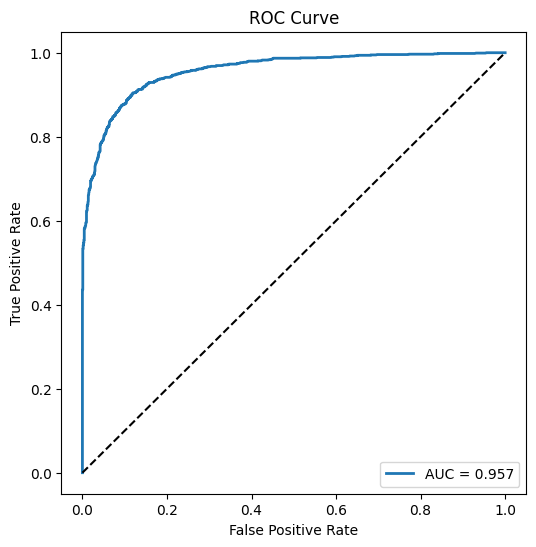

In [24]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9621523329488761


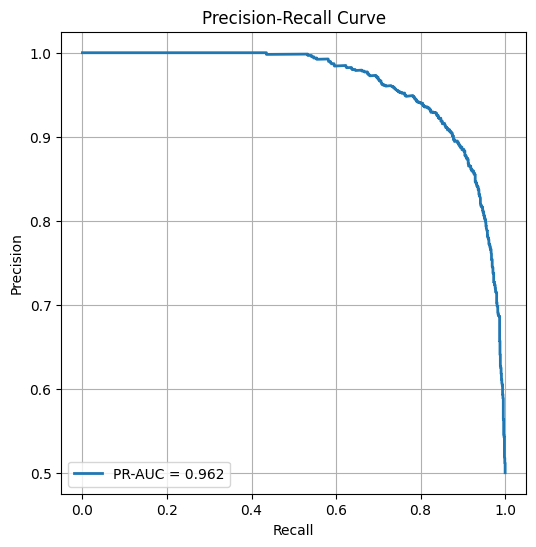

In [25]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

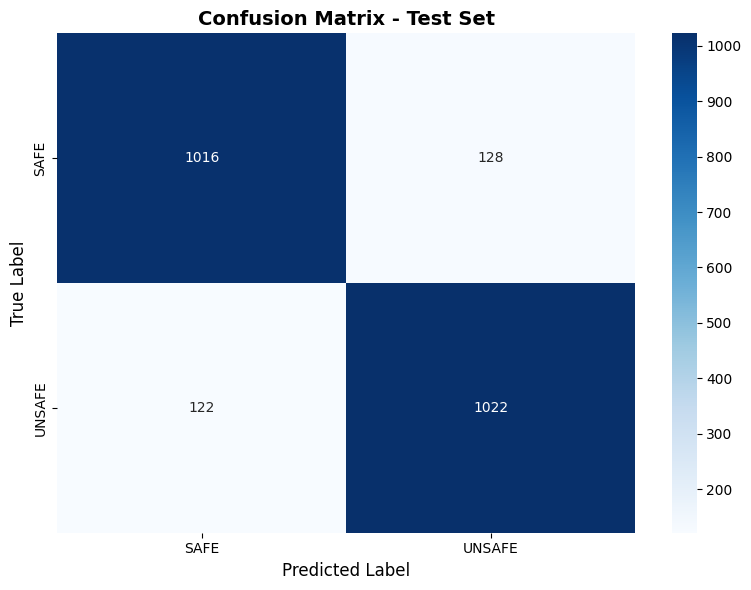

In [26]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

#### Save Model and Test

In [27]:
# Save the version currently in the trainer's brain
trainer.save_model("./my_final_bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


In [28]:
# TEST MODEL

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Load the model and tokenizer from your local folder
path = "./my_final_bert"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Ensure you saved the tokenizer there too!

# Create a 'pipeline' (the easiest way to use the model)
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6799.16it/s]


In [29]:
# Test it on a new sentence
result = classifier("kiss it from my lips")
print(result)

[{'label': 'LABEL_1', 'score': 0.9938687682151794}]


In [30]:
import accelerate
import transformers
import torch

print(f"Accelerate version: {accelerate.__version__}")
print(f"Transformers version: {transformers.__version__}")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Accelerate version: 1.13.0
Transformers version: 5.3.0
Torch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
